# Full Code Scanner


## Librairies


In [1]:
from PIL import Image
import os
from tqdm import tqdm
import glob
import re
import matplotlib as plt #! matplotib.pyplot no?
import math
from mpl_toolkits.mplot3d import Axes3D
import cv2
import numpy as np
import matplotlib.image as mpimg
import json

## Parameters

In [57]:
# Folders
folder_path = "/Users/julesloisance/Desktop/StageHelsinki/MoEDAL_Data_Apr2025/"
element = "O1_L8_ME18_UD1"
save_folder = "/Users/julesloisance/Desktop/StageHelsinki/CelianCodeResults/" + element 

# Create the folder if it doesn't exist
os.makedirs(save_folder, exist_ok=True)

# Regular expression to extract i and j values
pattern = re.compile(r'MoEDAL-(\d{3})-(\d{3})\.png') 

# In order to find the intervals of i and j no matter what the images are
i_values = []
j_values = []

# Parameters
num_columns = 3
num_rows = 4
step = 3  # number of images per column/row (3 by 3 mosaics)

total_width = num_columns * step      # 9 total width of the mosaics
total_height = num_rows * step        # 12 total height of the mosaics

# Loop through all files in the folder
for filename in os.listdir(folder_path + element):
    match = pattern.match(filename)
    if match:
        i = int(match.group(1))
        j = int(match.group(2))
        i_values.append(i)
        j_values.append(j)
        
# Compute min and max if matching files were found
if i_values and j_values:
    i_min, i_max = min(i_values), max(i_values)
    j_min, j_max = min(j_values), max(j_values)
    print(f"i_min: {i_min}, i_max: {i_max}")
    print(f"j_min: {j_min}, j_max: {j_max}")
else:
    print("No matching files found.")
    
# Important i and j values     
i_center = int((i_min + i_max) / 2)
j_center = int((j_min + j_max) / 2)

# Save the initial intervals for later absolute coordinate reference
i_initial_min = i_min
i_initial_max = i_max
j_initial_min = j_min
j_initial_max = j_max

# Define the mosaic borders properly centered around i_center and j_center (i_min and i_max are redefined)
i_min = i_center - (total_height // 2)
i_max = i_min + total_height - 1  # to have exactly 12 images

j_min = j_center - (total_width // 2)
j_max = j_min + total_width - 1   # to have exactly 9 images

print(i_min)
print(i_max)
print(j_min)
print(j_max)

# In case of having a non-multiple-of-3 length interval
num_row_operations = (i_max + 1 - i_min) // 3
num_column_operations = (j_max + 1 - j_min) // 3

new_row_min = i_min
new_column_min = j_min
new_row_max = i_min + num_row_operations * 3 - 1
new_column_max = j_min + num_column_operations * 3 - 1

# Number of pixels to cut to avoid ellipse duplication on borders
crop_width_X = 655   # will be cropped from the left
crop_height_Y = 295  # will be cropped from the bottom

# Paths and images
list_of_path_lists = []
list_of_image_lists = []

# List of resized images
list_of_resized_image_lists = []

# Absolute coordinates
width_0 = []
height_0 = []

# Sorting parameters
min_intensity = 0
max_intensity = 130

# Pixel resolution of the scanner
pixel_resolution = 1.75


i_min: 34, i_max: 62
j_min: 34, j_max: 55
42
53
40
48


## Loading of Images


In [58]:
# Path generation
for i in range(new_row_min, new_row_max + 1):
    path_list = [
        f"{folder_path}{element}/MoEDAL-{i:03}-{j:03}.png"  # Only the image name pattern may vary here
        for j in range(new_column_min, new_column_max + 1)
    ]
    list_of_path_lists.append(path_list)

print(list_of_path_lists)

# Image loading
print("\nLoading images...")
for path_list in tqdm(list_of_path_lists, desc="Rows"):
    images = []
    for path in path_list:
        if os.path.exists(path):
            images.append(Image.open(path))
        else:
            print(f"⚠️ Image not found: {path}")
    list_of_image_lists.append(images)

print(list_of_image_lists)


[['/Users/julesloisance/Desktop/StageHelsinki/MoEDAL_Data_Apr2025/O1_L8_ME18_UD1/MoEDAL-042-040.png', '/Users/julesloisance/Desktop/StageHelsinki/MoEDAL_Data_Apr2025/O1_L8_ME18_UD1/MoEDAL-042-041.png', '/Users/julesloisance/Desktop/StageHelsinki/MoEDAL_Data_Apr2025/O1_L8_ME18_UD1/MoEDAL-042-042.png', '/Users/julesloisance/Desktop/StageHelsinki/MoEDAL_Data_Apr2025/O1_L8_ME18_UD1/MoEDAL-042-043.png', '/Users/julesloisance/Desktop/StageHelsinki/MoEDAL_Data_Apr2025/O1_L8_ME18_UD1/MoEDAL-042-044.png', '/Users/julesloisance/Desktop/StageHelsinki/MoEDAL_Data_Apr2025/O1_L8_ME18_UD1/MoEDAL-042-045.png', '/Users/julesloisance/Desktop/StageHelsinki/MoEDAL_Data_Apr2025/O1_L8_ME18_UD1/MoEDAL-042-046.png', '/Users/julesloisance/Desktop/StageHelsinki/MoEDAL_Data_Apr2025/O1_L8_ME18_UD1/MoEDAL-042-047.png', '/Users/julesloisance/Desktop/StageHelsinki/MoEDAL_Data_Apr2025/O1_L8_ME18_UD1/MoEDAL-042-048.png'], ['/Users/julesloisance/Desktop/StageHelsinki/MoEDAL_Data_Apr2025/O1_L8_ME18_UD1/MoEDAL-043-040.pn

Rows: 100%|██████████| 12/12 [00:00<00:00, 318.63it/s]

[[<PIL.PngImagePlugin.PngImageFile image mode=RGB size=3840x2748 at 0x11DDE8EE0>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=3840x2748 at 0x11DE07100>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=3840x2748 at 0x11DE070D0>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=3840x2748 at 0x11DDDBFD0>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=3840x2748 at 0x11DDDB670>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=3840x2748 at 0x11DF7B040>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=3840x2748 at 0x11DF7B310>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=3840x2748 at 0x11DF7B1F0>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=3840x2748 at 0x11DF7B100>], [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=3840x2748 at 0x11DF7B340>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=3840x2748 at 0x11DE79F70>, <PIL.PngImagePlugin.PngImageFile image mode=RGB size=3840x2748 at 0x11DE79EB0>, <PIL.PngImagePlugin.PngImageFile ima

## Resize 

In [4]:
# Get the height of each image and determine the minimum
heights = [img.size[1] for row in list_of_image_lists for img in row]
new_height = min(heights)

# Resize and crop each image
for idx, row in enumerate(list_of_image_lists):
    resized_row = []
    print(f"Resizing row {idx + 1}...")

    for img in row:
        # In case all of the images don't have the same height, we resize them to the minimum height while keeping the aspect ratio
        new_width = int(img.size[0] * new_height / img.size[1])
        resized_img = img.resize((new_width, new_height), Image.LANCZOS)

        # Systematic cropping at the bottom
        resized_img = resized_img.crop((0, 0, resized_img.size[0], new_height - crop_height_Y))

        # Systematic cropping on the left
        resized_img = resized_img.crop((crop_width_X, 0, resized_img.size[0], resized_img.size[1]))

        resized_row.append(resized_img)

    list_of_resized_image_lists.append(resized_row)

# Update main image list
list_of_image_lists = list_of_resized_image_lists


Resizing row 1...
Resizing row 2...
Resizing row 3...
Resizing row 4...
Resizing row 5...
Resizing row 6...
Resizing row 7...
Resizing row 8...
Resizing row 9...
Resizing row 10...
Resizing row 11...
Resizing row 12...


## Creation of mosaics

In [59]:

# Delete old mosaics
for file in glob.glob(os.path.join(save_folder, "Mosaic*.png")):
    os.remove(file)

# Delete old associated JSON files
for file in glob.glob(os.path.join(save_folder, "Mosaic*.json")):
     os.remove(file)

# Build and save mosaics
for i in range(0, new_row_max - new_row_min + 1, step):
    row_images = [[] for _ in range(step)]

    for j in range(0, new_column_max - new_column_min, step):
        coords_dict = []

        # Build the 3 rows
        for k in range(step):
            img1 = list_of_image_lists[i + k][j]
            img2 = list_of_image_lists[i + k][j + 1]
            img3 = list_of_image_lists[i + k][j + 2]

            target_height = img1.size[1]
            total_width = img1.size[0] + img2.size[0] + img3.size[0]

            new_row = Image.new('RGB', (total_width, target_height), (255, 255, 255))

            widths = [img3.size[0], img2.size[0], img1.size[0]]
            images = [img3, img2, img1]

            x_offset = 0
            x_positions = []
            for img in images:
                x_positions.append(x_offset)
                x_offset += img.size[0]

            for idx_img, img in enumerate(images):
                new_row.paste(img, (x_positions[idx_img], 0))

            row_images[k] = new_row

        print(f"\nFinal vertical assembly of mosaic {int(i/3)+1} ; {int(j/3)+1}")
        total_height = sum(row.size[1] for row in row_images)
        final_width = max(row.size[0] for row in row_images)
        final_image = Image.new('RGB', (final_width, total_height), (255, 255, 255))

        y_offsets = [0, row_images[0].size[1], row_images[0].size[1] + row_images[1].size[1]]
        y_offsets = y_offsets[::-1]  # start from bottom

        for k in range(2, -1, -1):
            final_image.paste(row_images[k], (0, y_offsets[k]))

        # Final sorting (optional if not saving metadata)
        coords_dict = sorted(coords_dict, key=lambda x: (-int(x["name"][7:10]), int(x["name"][11:14])))

        # Save image
        filename = f"Mosaic_{int(i/3)+1}_{int(j/3)+1}.png"
        final_image.save(os.path.join(save_folder, filename))

        # Save metadata (disabled)
        # json_path = os.path.join(save_folder, f"Mosaic_{int(i/3)+1}_{int(j/3)+1}.json")
        # with open(json_path, 'w') as f_json:
        #     json.dump({filename: coords_dict}, f_json, indent=4)


# JSON structure example:
# {
#   "Mosaic_1_1.png": [
#     {"name": "MoEDAL-000-000.png", "coords": [x_min, y_min, x_max, y_max]},
#     {"name": "MoEDAL-000-001.png", "coords": [x_min, y_min, x_max, y_max]},
#     ...
#   ],
#   "Mosaic_1_2.png": [
#     ...
#   ]
# }



Final vertical assembly of mosaic 1 ; 1

Final vertical assembly of mosaic 1 ; 2

Final vertical assembly of mosaic 1 ; 3

Final vertical assembly of mosaic 2 ; 1

Final vertical assembly of mosaic 2 ; 2

Final vertical assembly of mosaic 2 ; 3

Final vertical assembly of mosaic 3 ; 1

Final vertical assembly of mosaic 3 ; 2

Final vertical assembly of mosaic 3 ; 3

Final vertical assembly of mosaic 4 ; 1

Final vertical assembly of mosaic 4 ; 2

Final vertical assembly of mosaic 4 ; 3


## Absolute Coordinates


Click approximately on the center of the hole (one click)


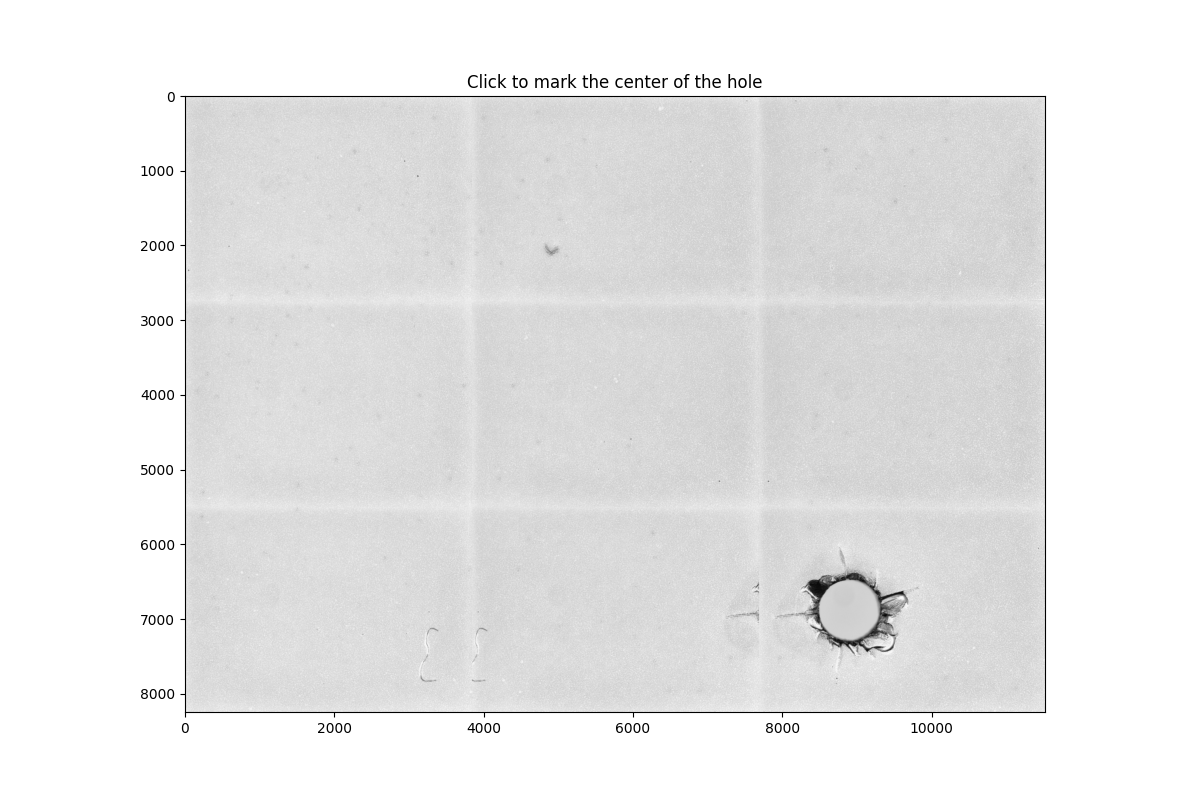

In [60]:
%matplotlib widget
import matplotlib.pyplot as plt

#   Adjustable parameters 
threshold = 60

# Mosaic indices
i = 1
j = 1
image_path = f"/Users/julesloisance/Desktop/StageHelsinki/CelianCodeResults/{element}/Mosaic_{i}_{j}.png"

# Load the image
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("❌ Image not found. Please check the path or filename.")

print("Click approximately on the center of the hole (one click)")

clicked_coords = []

def on_click_center(event):
    if event.xdata is not None and event.ydata is not None:
        x, y = int(event.xdata), int(event.ydata)
        clicked_coords.append((x, y))
        # Display red point
        ax.plot(x, y, 'rx', markersize=10)
        fig.canvas.draw()
        print(f"✅ Center selected at: ({x}, {img.shape[0]-y})")
        # Disconnect event and close the window
        fig.canvas.mpl_disconnect(cid)
       #plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img, cmap='gray')
 
cid = fig.canvas.mpl_connect('button_press_event', on_click_center)
plt.title("Click to mark the center of the hole")
plt.show()
# Wait for the user to click and close the window before proceeding


# if not clicked_coords:
#     raise ValueError("❌ No point selected.")

# x0, y0 = clicked_coords[0]

# # Sub-image dimensions (assumed identical for all)
# new_width, new_height = list_of_image_lists[0][0].size

# # Determine the indices of the sub-image containing (x0, y0)
# i_sub = x0 // new_width + 1
# j_sub = (2 - (y0 // new_height)) + 1  # because j increases upward

# print(f"📍 The center is in image_{j_sub}_{i_sub}")

# # --- Re-display image with center point and cross lines ---
# fig2, ax2 = plt.subplots(figsize=(12, 8))
# ax2.imshow(img, cmap='gray')
# ax2.plot(x0, y0, 'rx', markersize=10, label='Center point')
# ax2.axvline(x=x0, color='r', linestyle='--')
# ax2.axhline(y=y0, color='r', linestyle='--')
# plt.title("Select left border point and then top border point (two clicks)")
# plt.legend()

# border_coords = []

# def on_click_borders(event):
#     if event.xdata is not None and event.ydata is not None and len(border_coords) < 2:
#         x, y = int(event.xdata), int(event.ydata)
#         border_coords.append((x, img.shape[0]-y))
#         ax2.plot(x, y, 'bo', markersize=10)  # border points in blue
#         fig2.canvas.draw()
#         print(f"✅ Border point {len(border_coords)} selected at: ({x}, {img.shape[0]-y})")
#         if len(border_coords) == 2:
#             print("\n✅ Both border points selected:")
#             print(f"Left border: {border_coords[0]}")
#             print(f"Top border: {border_coords[1]}")
#             fig2.canvas.mpl_disconnect(cid2)
#             plt.close(fig2)

# cid2 = fig2.canvas.mpl_connect('button_press_event', on_click_borders)
# plt.show()

# y0 = img.shape[0] - y0

# print(x0, y0)



📍 The center is in image_1_3


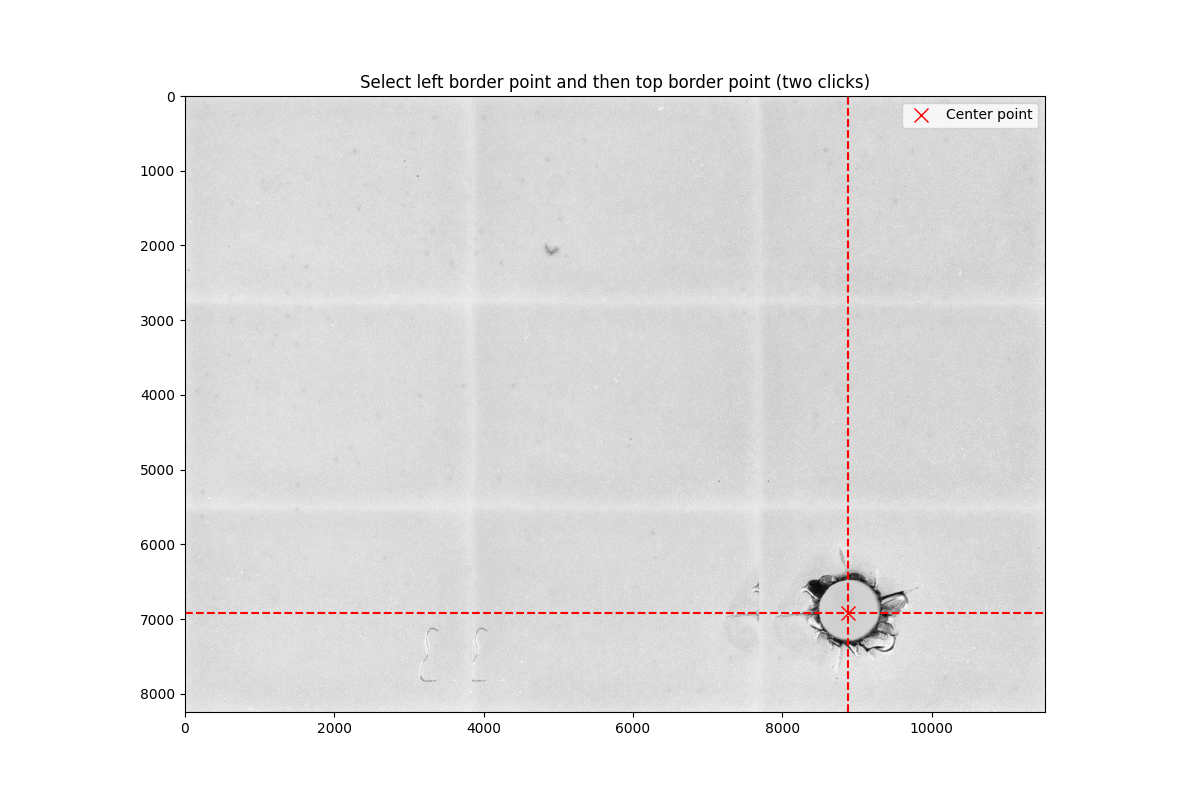

Final saved coordinates for processing: x0=8883, y0=1320


In [61]:
if not clicked_coords:
    raise ValueError("❌ No point selected.")

x0, y0 = clicked_coords[0]

# Sub-image dimensions (assumed identical for all)
new_width, new_height = list_of_image_lists[0][0].size

# Determine the indices of the sub-image containing (x0, y0)
i_sub = x0 // new_width + 1
j_sub = (2 - (y0 // new_height)) + 1  # because j increases upward

print(f"📍 The center is in image_{j_sub}_{i_sub}")

# --- Re-display image with center point and cross lines ---
fig2, ax2 = plt.subplots(figsize=(12, 8))
ax2.imshow(img, cmap='gray')
ax2.plot(x0, y0, 'rx', markersize=10, label='Center point')
ax2.axvline(x=x0, color='r', linestyle='--')
ax2.axhline(y=y0, color='r', linestyle='--')
plt.title("Select left border point and then top border point (two clicks)")
plt.legend()

border_coords = []

def on_click_borders(event):
    if event.xdata is not None and event.ydata is not None and len(border_coords) < 2:
        x, y = int(event.xdata), int(event.ydata)
        border_coords.append((x, img.shape[0]-y))
        ax2.plot(x, y, 'bo', markersize=10)  # border points in blue
        fig2.canvas.draw()
        print(f"✅ Border point {len(border_coords)} selected at: ({x}, {img.shape[0]-y})")
        if len(border_coords) == 2:
            print("\n✅ Both border points selected:")
            print(f"Left border: {border_coords[0]}")
            print(f"Top border: {border_coords[1]}")
            fig2.canvas.mpl_disconnect(cid2)
            #plt.close(fig2)

cid2 = fig2.canvas.mpl_connect('button_press_event', on_click_borders)
plt.show()

y0 = img.shape[0] - y0

print(f"Final saved coordinates for processing: x0={x0}, y0={y0}")


## Sort the best mosaic by angles and intensities of the ellipses (to much time to be proceded)

In [70]:
mosaic_folder = os.path.join(save_folder)

# Filtering parameters
min_intensity = 0
max_intensity = 130

# Retrieve all mosaic files
mosaic_files = sorted([f for f in os.listdir(mosaic_folder) 
                       if f.startswith("Mosaic_") and f.endswith(".png")])

mosaic_names = []
interesting_counts = []

for mosaic_file in mosaic_files:
    path = os.path.join(mosaic_folder, mosaic_file)
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 10)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    ellipse_count = 0

    for cnt in contours:
        if len(cnt) >= 5:
            ellipse = cv2.fitEllipse(cnt)
            (cx, cy), (major, minor), angle = ellipse

            if major <= 0 or minor <= 0 or math.isnan(major) or math.isnan(minor):
                continue  # Skip this ellipse

            mask = np.zeros_like(image, dtype=np.uint8)
            cv2.ellipse(mask, ellipse, (255,), thickness=-1)
            masked_pixels = image[mask == 255]
            mean_intensity = np.mean(masked_pixels) if len(masked_pixels) > 0 else 0

            if min_intensity < mean_intensity < max_intensity:
                ellipse_count += 1

    mosaic_names.append(mosaic_file.replace(".png", ""))
    interesting_counts.append(ellipse_count)

# Display the histogram
plt.figure(figsize=(14, 6))
plt.bar(mosaic_names, interesting_counts, color='skyblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Mosaic name")
plt.ylabel("Number of interesting ellipses")
plt.title(f"Histogram of mosaics ({element})\nIntensity ∈ [{min_intensity}, {max_intensity}]")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# (Optional) Save the histogram
plt.savefig(os.path.join(save_folder, f"Histogram_ellipses_{element}.png"))


FileNotFoundError: [Errno 2] No such file or directory: '/Users/julesloisance/Desktop/StageHelsinki/CelianCodeResults/O1_L8_ME18_UD1/'

## Histogram Angle

Analyzing: /Users/julesloisance/Desktop/StageHelsinki/CelianCodeResults/O1_L8_ME18_UD1/Mosaic_3_1.png
🧭 Dominant angle: 165°


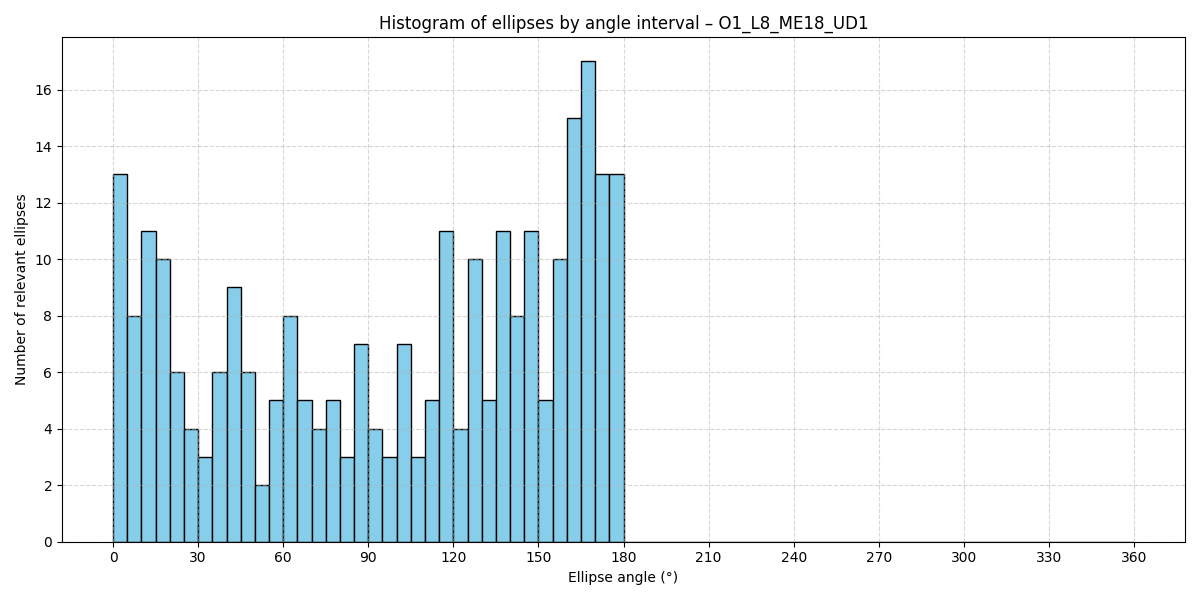

In [63]:
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import os

# Parameters
i = 3
j = 1
element = "O1_L8_ME18_UD1"
image_path = f"/Users/julesloisance/Desktop/StageHelsinki/CelianCodeResults/{element}/"
image_name = f"Mosaic_{i}_{j}.png"
save_folder = image_path  # Files will be saved in the same folder

print("Analyzing:", image_path + image_name)

# Load and preprocess the image
image = cv2.imread(image_path + image_name, cv2.IMREAD_GRAYSCALE)
blurred = cv2.GaussianBlur(image, (5, 5), 0)
thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY_INV, 15, 10)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Angular histogram
num_bins = 360 // 5
ellipse_histogram = np.zeros(num_bins, dtype=int)
angle_bins = np.arange(0, 360, 5)

# Process contours
for cnt in contours:
    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        (cx, cy), (major, minor), angle = ellipse
        if math.isnan(major) or math.isnan(minor):
            continue

        # Intensity filtering
        mask = np.zeros_like(image, dtype=np.uint8)
        cv2.ellipse(mask, ellipse, (255,), thickness=-1)
        masked_pixels = image[mask == 255]
        mean_intensity = np.mean(masked_pixels) if masked_pixels.size > 0 else 0

        if 80 < mean_intensity < 140: #! aren't min and max intensity defined earlier?
            bin_index = int(angle // 5) % num_bins
            ellipse_histogram[bin_index] += 1

# Dominant angle
dominant_bin_index = int(np.argmax(ellipse_histogram))
dominant_angle = dominant_bin_index * 5
print(f"🧭 Dominant angle: {dominant_angle}°")

# Display histogram
plt.figure(figsize=(12, 6))
plt.bar(angle_bins, ellipse_histogram, width=5, align='edge', color='skyblue', edgecolor='black')
plt.xlabel("Ellipse angle (°)")
plt.ylabel("Number of relevant ellipses")
plt.title(f"Histogram of ellipses by angle interval – {element}")
plt.xticks(np.arange(0, 361, 30))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Save the histogram (optional)
# plt.savefig(os.path.join(save_folder, f"angle_histogram_{element}.png"))


## Highlight ellipses from the best interval of angles 


Detected ellipses (correct angle + correct intensity):
x = 7782.67, y = 4306.97, intensity = 126.67
x = 7126.52, y = 4308.08, intensity = 123.99
x = 6308.61, y = 6352.28, intensity = 129.26

→ Coordinates of red ellipses saved to /Users/julesloisance/Desktop/StageHelsinki/CelianCodeResults/O1_L8_ME18_UD1//Mosaic_2_1_ellipses_red.json


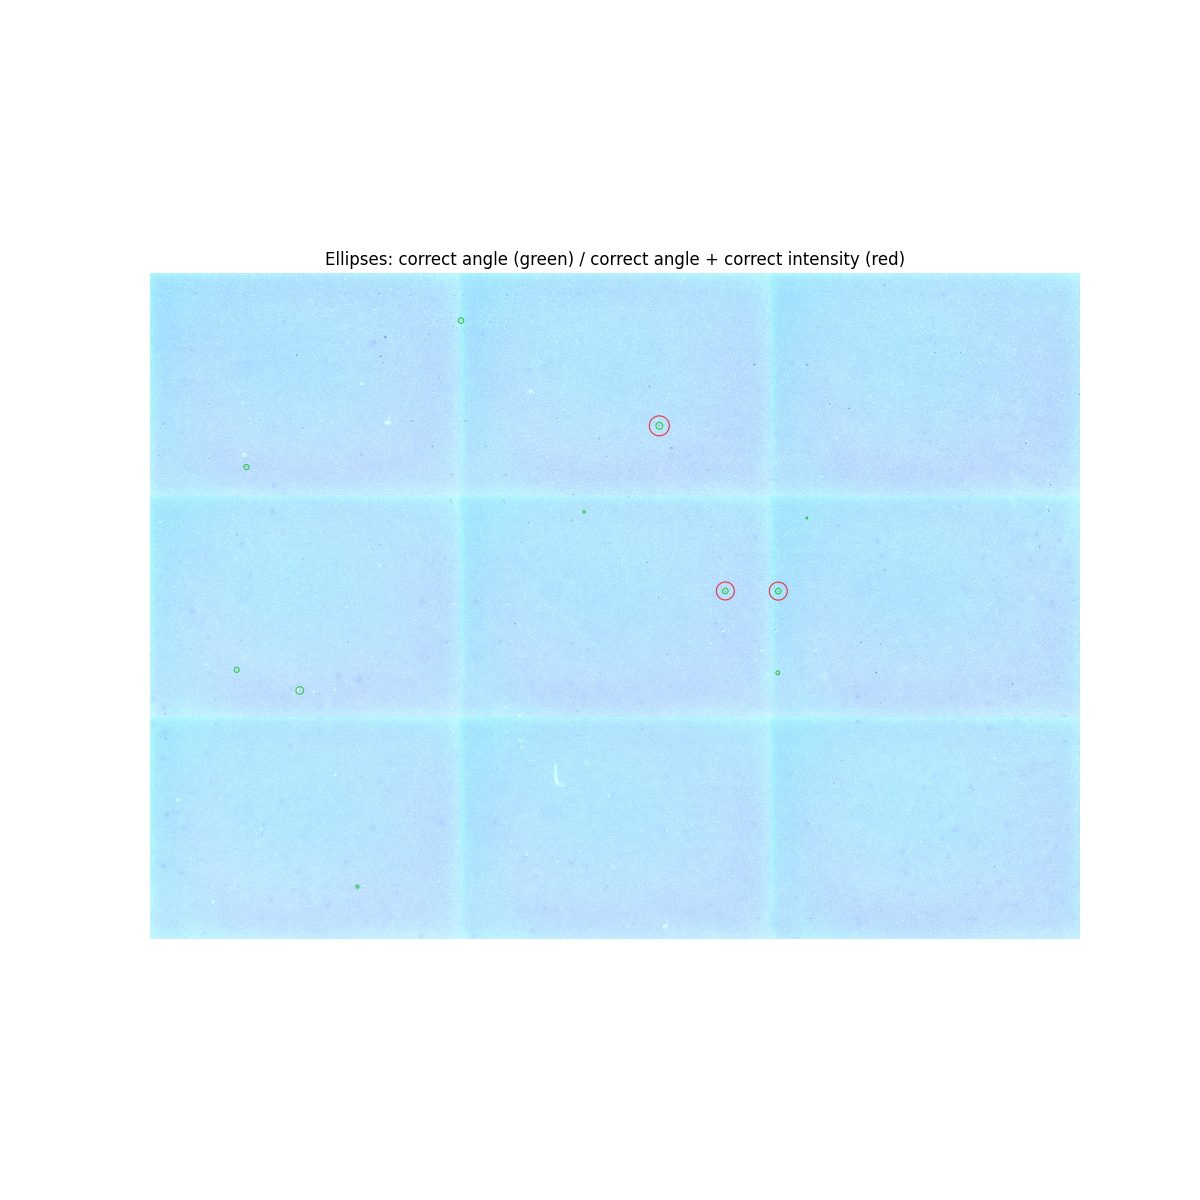

In [64]:
# Remove old associated JSON files
for file in glob.glob(os.path.join(image_path, "*.json")):
    os.remove(file)

# Parameters.
i = 2
j = 1
element = "O1_L8_ME18_UD1"
image_path = f"/Users/julesloisance/Desktop/StageHelsinki/CelianCodeResults/{element}/"
image_name = f"Mosaic_{i}_{j}.png"

image = cv2.imread(image_path + image_name, cv2.IMREAD_GRAYSCALE)

blurred = cv2.GaussianBlur(image, (5, 5), 0)
thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY_INV, 15, 10)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

xpos = []
ypos = []
el_major = []
el_minor = []
el_angle = []
pit_intensity = []
super_image_height, super_image_width = image.shape[:2]
local_ellipse_count = 0

green_threshold = 170
angle = dominant_angle
min_intensity = 0
max_intensity = 130
ellipse_counts = {}

red_ellipses_data = []

image_rgb = cv2.cvtColor(cv2.imread(image_path + image_name), cv2.COLOR_BGR2RGB)

print("\nDetected ellipses (correct angle + correct intensity):")

for cnt in contours:
    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        (cx, cy), (major, minor), angle1 = ellipse

        if angle <= angle1 <= angle + 5 and not math.isnan(major) and not math.isnan(minor):

            # Compute mean intensity within the ellipse
            mask = np.zeros_like(image, dtype=np.uint8)
            cv2.ellipse(mask, ellipse, (255,), thickness=-1)
            masked_pixels = image[mask == 255]
            mean_intensity = np.mean(masked_pixels) if len(masked_pixels) > 0 else 0
            pit_intensity.append(mean_intensity)

            if mean_intensity < green_threshold:
                # Local coordinates with origin at bottom left
                x_local = cx
                y_local = image.shape[0] - cy

                xpos.append(x_local)
                ypos.append(y_local)
                el_major.append(major)
                el_minor.append(minor)
                el_angle.append(angle1)

                # Green circle = correct angle
                radius_green = int(max(major, minor) * 3)
                cv2.circle(image_rgb, (int(cx), int(cy)), radius_green, (9, 200, 9), 10)

                # Red circle = correct angle + correct intensity
                if min_intensity <= mean_intensity <= max_intensity:
                    radius_red = int((major + minor) * 5)
                    cv2.circle(image_rgb, (int(cx), int(cy)), radius_red, (255, 0, 0), 10)

                    # Display coordinates in console
                    print(f"x = {x_local:.2f}, y = {y_local:.2f}, intensity = {mean_intensity:.2f}")
                    red_ellipses_data.append({
                        "x": round(x_local, 2),
                        "y": round(y_local, 2),
                        "intensity": round(mean_intensity, 2),
                        "major": round(major, 2),
                        "minor": round(minor, 2),
                        "angle": round(angle1, 2)
                    })
                local_ellipse_count += 1

ellipse_counts[image_name] = local_ellipse_count

# Save to a JSON file
json_filename = f"{image_path}/Mosaic_{i}_{j}_ellipses_red.json"
with open(json_filename, "w") as f:
    json.dump(red_ellipses_data, f, indent=4)

print(f"\n→ Coordinates of red ellipses saved to {json_filename}")

plt.figure(figsize=(12, 12))
plt.imshow(image_rgb)
plt.title("Ellipses: correct angle (green) / correct angle + correct intensity (red)")
plt.axis('off')
plt.show()


## Linked Coordinates


In [65]:
import json
import os

# Known parameters

pixel_resolution=1.75

# Reference hole indices and ellipse mosaic indices
i_trou, j_trou = 1, 1
i_ellipse, j_ellipse = i,j 

# Mosaic dimensions (height, width)
mosaic_height, mosaic_width = image_rgb.shape[:2]
total_height = num_rows * mosaic_height

# Path to JSON file containing red ellipses
element = "O1_L8_ME18_UD1"
image_path = f"/Users/julesloisance/Desktop/StageHelsinki/CelianCodeResults/{element}/"
image_name = f"Mosaic_{i}_{j}.png"
json_file = f"{image_path}{image_name.replace('.png', '_ellipses_red.json')}"

# Load ellipse data
with open(json_file, "r") as f:
    ellipses = json.load(f)

# Global coordinates of the reference hole (global origin is the top left corner of the entire mosaic patchwork)
# x_global goes from left to right, y_global goes from top to bottom
x0_global = x0 + (num_columns - j_trou) * mosaic_width
y0_global = (num_rows - i_trou) * mosaic_height + (mosaic_height - y0)  # because y increases downward in images

# Convert local ellipse coords to global and then to relative coords
relocated_ellipses = []
for ell in ellipses:
    x_local = ell["x"]
    y_local = ell["y"]

    x_global = x_local + (num_columns - j_ellipse) * mosaic_width
    y_global = (num_rows - i_ellipse) * mosaic_height + (mosaic_height - y_local)

    x_global = float(x_global)
    x0_global = float(x0_global)
    y_global = float(y_global)
    y0_global = float(y0_global)
    pixel_resolution = float(pixel_resolution)

    x_relatif = (x_global - x0_global) * pixel_resolution
    y_relatif = (y_global - y0_global) * pixel_resolution

    ell_modifiee = ell.copy()
    ell_modifiee["x_global"] = round(x_global, 2)
    ell_modifiee["y_global"] = round(y_global, 2)
    ell_modifiee["x_relatif"] = round(x_relatif, 2)
    ell_modifiee["y_relatif"] = round(y_relatif, 2)

    relocated_ellipses.append(ell_modifiee)

# Sauvegarde
new_json = json_file.replace(".json", "_relatif_au_trou.json")
with open(new_json, "w") as f:
    json.dump(relocated_ellipses, f, indent=4)

print(f"✅ Global and relative coordinates stored in {new_json}")


✅ Global and relative coordinates stored in /Users/julesloisance/Desktop/StageHelsinki/CelianCodeResults/O1_L8_ME18_UD1/Mosaic_2_1_ellipses_red_relatif_au_trou.json


Mosaic dimensions: 8244 11520
Total dimensions: 34560 32976


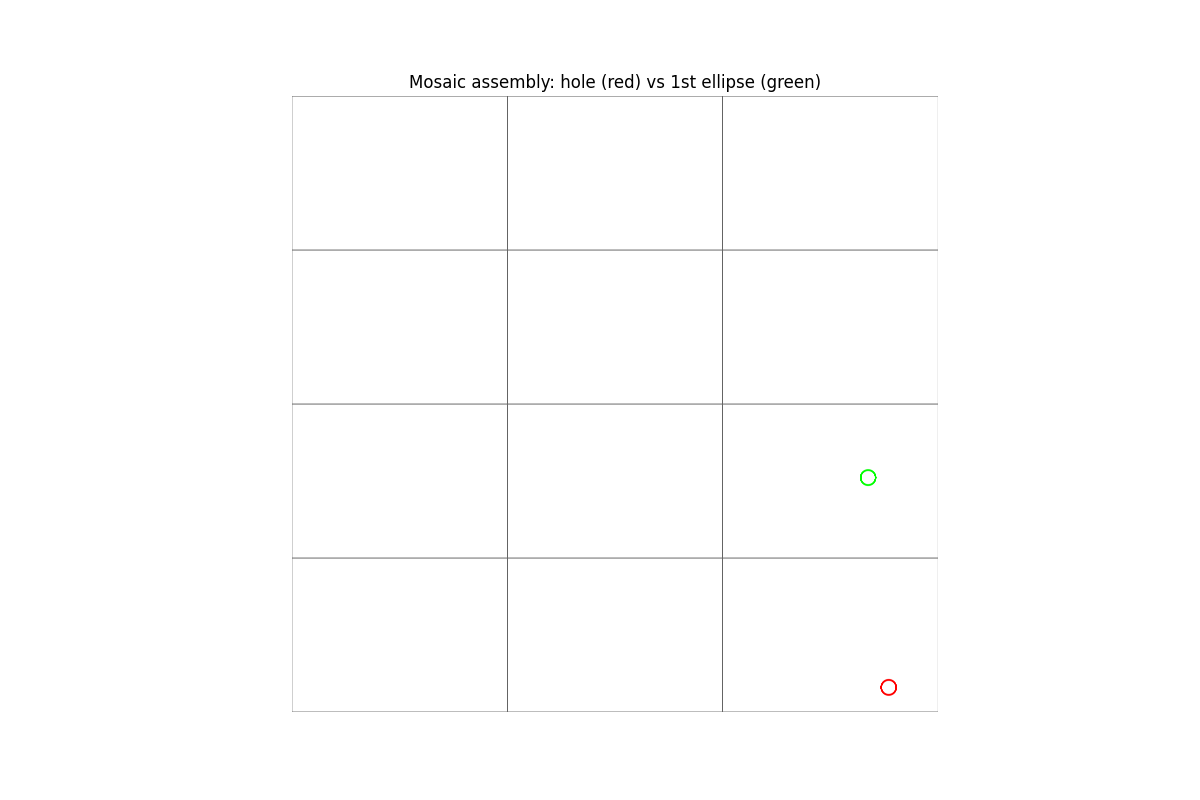

Global coordinates of the hole: 31923 31656
Global coordinates of the 1st ellipse: 30822.67 20425.03


In [66]:
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt

image_rgb = cv2.cvtColor(cv2.imread(image_path + image_name), cv2.COLOR_BGR2RGB)

mosaic_height, mosaic_width = image_rgb.shape[:2]

print("Mosaic dimensions:", mosaic_height, mosaic_width)

num_rows = 4 # number of row of mosaic created
num_columns = 3 # numbre of columns of mosaic created

#  Hole position 
i_hole, j_hole = 1, 1

#  Load ellipses relative to the hole 
json_file = f"{image_path}Mosaic_{i}_{j}_ellipses_red_relatif_au_trou.json"
with open(json_file, "r") as f:
    ellipses = json.load(f)

#  Create a white canvas representing the full assembly 
total_width = num_columns * mosaic_width
total_height = num_rows * mosaic_height
print("Total dimensions:", total_width, total_height)
canvas = np.ones((total_height, total_width, 3), dtype=np.uint8) * 255

#  Grid line color and thickness 
line_color = (100, 100, 100)  # dark gray
line_thickness = 50  # reasonable thickness

# Draw horizontal grid lines
for row in range(num_rows + 1):
    y = row * mosaic_height
    cv2.line(canvas, (0, y), (total_width, y), line_color, line_thickness)

# Draw vertical grid lines
for col in range(num_columns + 1):
    x = col * mosaic_width
    cv2.line(canvas, (x, 0), (x, total_height), line_color, line_thickness)

#  Calculate global coordinates of the hole center 
# Note: x0, y0 must be defined (relative position inside the mosaic)
# x0, y0 = 75, 50  # example: approximate center in image_rgb (adapt accordingly)

x0_global = x0 + (num_columns - j_trou) * mosaic_width
y0_global = (num_rows - i_trou) * mosaic_height + (mosaic_height - y0) 

#  Display the hole (red) 
cv2.circle(canvas, (int(x0_global), int(y0_global)), 400, (0, 0, 255), 100)

#  Display the first ellipse (green) 
x1 = ellipses[0]["x_global"]
y1 = ellipses[0]["y_global"]

cv2.circle(canvas, (int(x1), int(y1)), 400, (0, 255, 0), 100)

#  Display with matplotlib 
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title("Mosaic assembly: hole (red) vs 1st ellipse (green)")
plt.axis('off')
plt.show()

#  Debug print 
print("Global coordinates of the hole:", x0_global, y0_global)
print("Global coordinates of the 1st ellipse:", x1, y1)


## Histogram Surfaces

/Users/julesloisance/Desktop/StageHelsinki/CelianCodeResults/O1_L8_ME18_UD1/
True


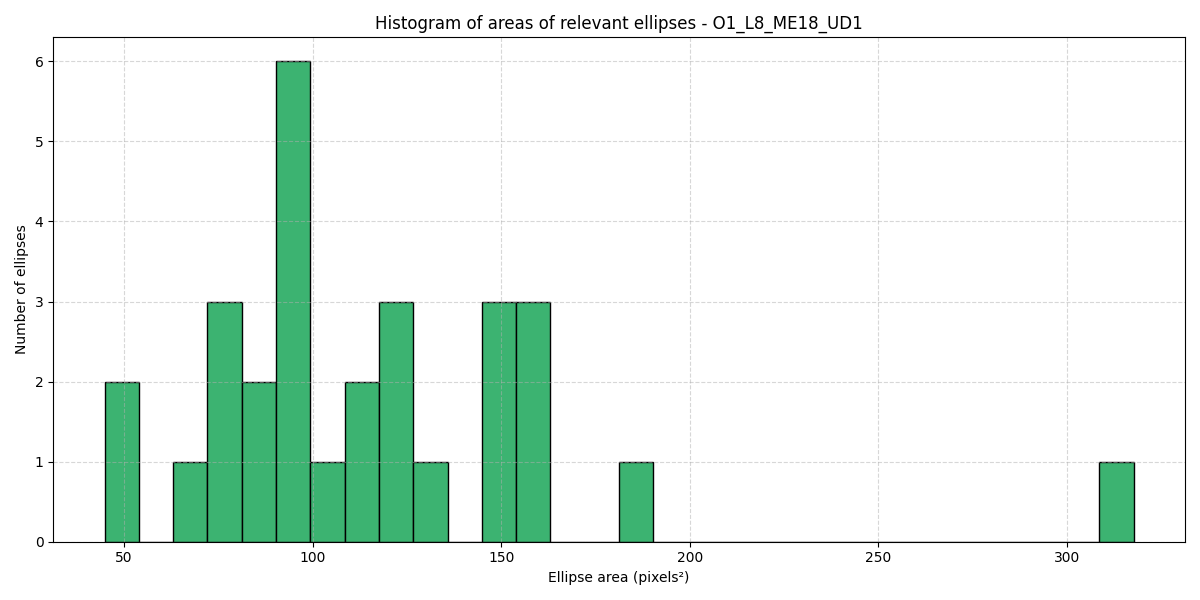

In [68]:
import importlib
importlib.reload(plt)
import matplotlib.pyplot as plt
import cv2
import numpy as np
import math
import os

# Read and preprocess
image = cv2.imread(image_path + image_name, cv2.IMREAD_GRAYSCALE)
blurred = cv2.GaussianBlur(image, (5, 5), 0)
thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY_INV, 15, 10)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# List to store areas of relevant ellipses
ellipse_areas = []

# Process contours
for contour in contours:
    if len(contour) >= 5:
        ellipse = cv2.fitEllipse(contour)
        (cx, cy), (major_axis, minor_axis), angle = ellipse
        if math.isnan(major_axis) or math.isnan(minor_axis):
            continue

        mask = np.zeros_like(image, dtype=np.uint8)
        cv2.ellipse(mask, ellipse, (255,), thickness=-1)
        masked_pixels = image[mask == 255]
        mean_intensity = np.mean(masked_pixels) if masked_pixels.size > 0 else 0

        if min_intensity < mean_intensity < max_intensity:
            area = math.pi * (major_axis / 2) * (minor_axis / 2)
            ellipse_areas.append(area)

# Plot histogram of ellipse areas
plt.figure(figsize=(12, 6))
plt.hist(ellipse_areas, bins=30, color='mediumseagreen', edgecolor='black')
plt.xlabel("Ellipse area (pixels²)")
plt.ylabel("Number of ellipses")
plt.title(f"Histogram of areas of relevant ellipses - {element}")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

print(save_folder)
print(os.path.exists(save_folder))

# plt.savefig(save_folder + f"histo_areas_{element}.png")
#! this should work better ⬇
plt.savefig(os.path.join(save_folder, f"histo_areas_{element}.png"))
plt.show()
